In [1]:
#===============================================================================
#   図　2.6   教師データセット
#   図　2.7   3次多項式によるフィッティング
#   図　2.8   9次多項式によるフィッティング
#   図　2.9   フィッティング結果の比較
#   図　2.10  検証データセット
#   図　2.11  検証データセットによる汎化性能の評価
#   図　2.13  1個抜き交差検証
#   図　2.14  2つの交差検証方法の比較
#
#   Copyright (c) 2024, Yuukou TOYONORI
#   All rights reserved.
#===============================================================================

## 教師あり学習：　$M$次多項式による回帰
- １次元教師データ（$n$点）：　$\mathcal{D}=\{(x_i, y_i)\,|\,i=1,2,\cdots,n\}$
- 回帰モデル（$M$次多項式）：　$f\,(x,\mathbf{w})=\displaystyle{\sum_{d=0}^M w_d x^d}$
- 重みベクトル：　　　　　　　$\mathbf{w}=(w_0,w_1,\cdots,w_M)^\top$<br><br>

#### ライブラリのインポートとフォントの指定

In [2]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams['font.family']      = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['text.usetex']      = True
plt.rcParams['font.size']        = 12
plt.rcParams['axes.labelsize']   = 'xx-large'

#### 汎化性能評価のための平均二乗誤差の定義
- $E_{\rm rms}=\displaystyle{\sqrt{\sum_{i=1}^n (f\,(x_i,\mathbf{w})-y_i)^2 \,/\,n}}$

In [3]:
def Erms (X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))

#### １０点の教師データの設定

In [4]:
xtrain = np.array([ 0.02, 0.22, 0.44,  0.67,  0.90, 0.16, 0.34, 0.50,  0.73,  1.00 ])
ytrain = np.array([-0.02, 0.97, 0.25, -0.90, -0.53, 0.94, 0.85, 0.12, -0.93,  0.08 ])
offset = np.array([    1,   -1,    1,     1,     1,    1,    1,   -1,    -1,    -1 ])

#### 教師データの散布図のプロット

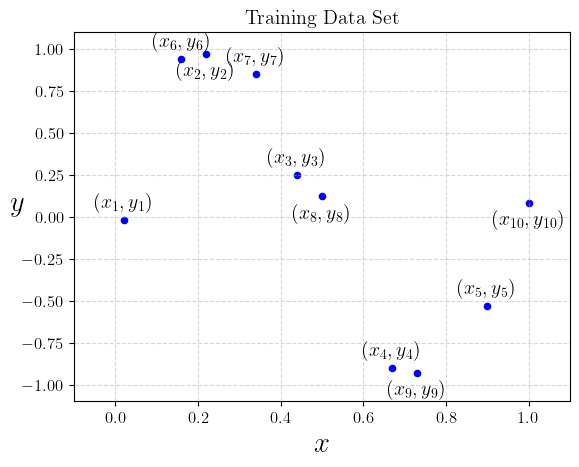

In [5]:
fig, ax = plt.subplots(dpi=100)
ax.scatter(xtrain, ytrain, marker='o', s=20, color='blue')
for i, row in enumerate(xtrain):
    ax.text(xtrain[i], ytrain[i] + offset[i] * 0.1, '$(x_{' + str(i + 1) + '},y_{' + str(i + 1) + '})$',
            ha='center', va='center', size='large')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation='horizontal')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Training Data Set')
plt.show()

#### ３次多項式による回帰曲線をプロット

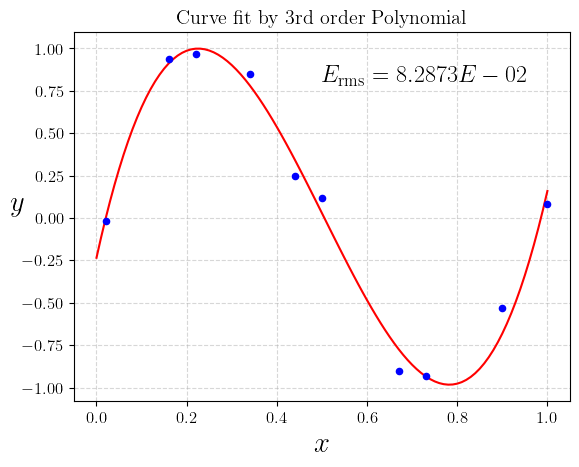

In [6]:
W3 = Polynomial.fit(xtrain, ytrain, deg=3)
x  = np.linspace(0, 1, 101)
# %%
fig, ax = plt.subplots(dpi=100)
ax.scatter(xtrain, ytrain, marker='o', s=20, color='blue', zorder=3)
ax.plot(x, W3(x), color='red')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation='horizontal')
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Curve fit by 3rd order Polynomial')
ax.text(0.5, 0.8, r'$E_{\rm rms} = %.4E$' % Erms(ytrain, W3(xtrain)), fontsize='x-large')
plt.show()

#### ９次多項式による回帰曲線をプロット

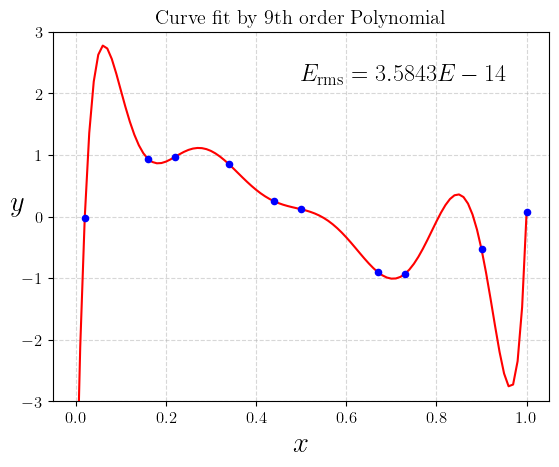

In [7]:
W9 = Polynomial.fit(xtrain, ytrain, deg=9)
# %%
fig, ax = plt.subplots(dpi=100)
ax.scatter(xtrain, ytrain, marker='o', s=20, color='blue', zorder=3)
ax.plot(x, W9(x), color='red')
ax.set_ylim([-3, 3])
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation='horizontal')
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Curve fit by 9th order Polynomial')
ax.text(0.5,2.2, r'$E_{\rm rms} = %.4E$' % Erms(ytrain, W9(xtrain)), fontsize='x-large')
plt.show()

#### 教師データの基になった正弦波と２つの回帰曲線
- ９次多項式の場合、$E_{\rm rms}\simeq 0\,$であるが、いわゆる過学習（overfitting）が発生している

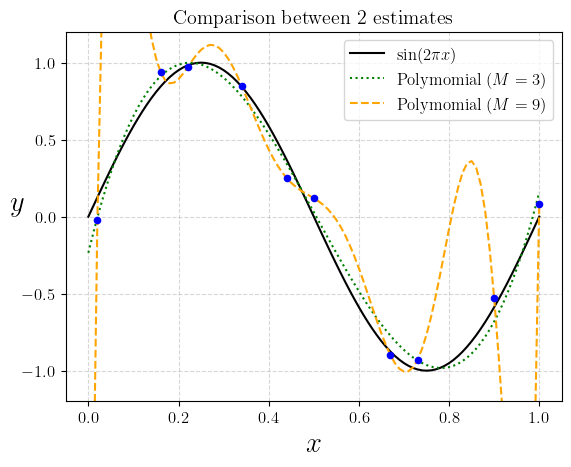

In [8]:
fig, ax = plt.subplots(dpi=100)
ax.scatter(xtrain, ytrain, marker='o', s=20, color='blue', zorder=3)
ax.plot(x, np.sin(2 * np.pi * x), color='black', label=r'$\sin(2\pi x$)',    linestyle='solid')
ax.plot(x, W3(x),                 color='green', label='Polymomial ($M=3$)', linestyle='dotted')
ax.plot(x, W9(x),                 color='orange',label='Polymomial ($M=9$)', linestyle='dashed')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation='horizontal')
ax.set_ylim(-1.2, 1.2)
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Comparison between 2 estimates')
plt.legend(loc='upper right')
plt.show()

#### テストデータによる汎化性能の評価
- 教師データと等しい数のテストデータを準備

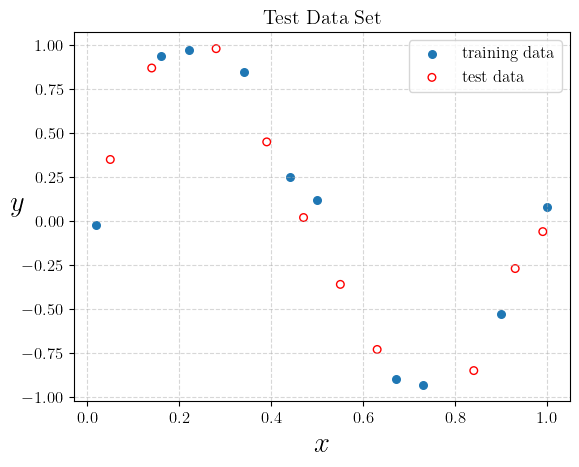

In [9]:
x_test = np.array([ 0.05, 0.14,  0.28,  0.39,  0.47,  0.55,  0.63,  0.93,  0.84,  0.99])
y_test = np.array([ 0.35, 0.87,  0.98,  0.45,  0.02, -0.36, -0.73, -0.27, -0.85, -0.06])
# %%
fig, ax = plt.subplots(dpi=100)
ax.scatter(xtrain, ytrain, marker='o', s=30, label='training data')
ax.scatter(x_test, y_test, marker='o', s=30, color='none', edgecolor='red', label='test data')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$', rotation='horizontal')
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Test Data Set')
plt.legend(loc='upper right')
plt.show()

#### ホールドアウト検証
全てのデータセットを任意の割合で学習データ、テストデータに分割して検証する方法
- $k$-fold 交差検証
    - データセットを$\,k\, $個のグループに分割
    - $(k-1)\,$個のグループを教師データ、残りをテストデータとして検証
    - $k\,$回のスコアの平均で汎化性能を評価する<br>
        <img src='UQ_ML_1a.png' width='15%'>

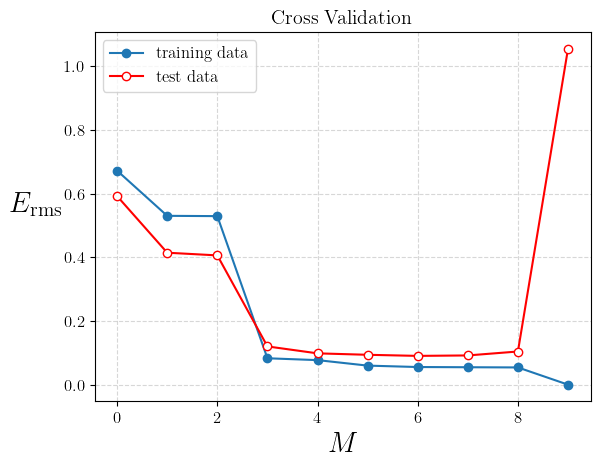

In [10]:
Erms_train, Erms_test = [], []
for d in range(10):
    W = Polynomial.fit(xtrain, ytrain, deg=d)
    Erms_train = np.hstack([Erms_train, Erms(ytrain, W(xtrain))])
    Erms_test  = np.hstack([Erms_test,  Erms(y_test,  W(x_test)) ])
# %%
fig, ax = plt.subplots(dpi=100)
ax.plot(np.array(range(10)), Erms_train, marker='o', markersize=6, label='training data')
ax.plot(np.array(range(10)), Erms_test,  marker='o', markersize=6, color='red', markerfacecolor='white', label='test data')
ax.set_xlabel('$M$')
ax.set_ylabel(r'$E_{\rm rms}$', rotation='horizontal', labelpad=20)
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('Cross Validation')
plt.legend(loc='upper left')
plt.show()

#### １個抜き検証（Leave-one-out, LOO)
- データセットの点数を$\,n\,$としたときの$\,n$-fold交差検証

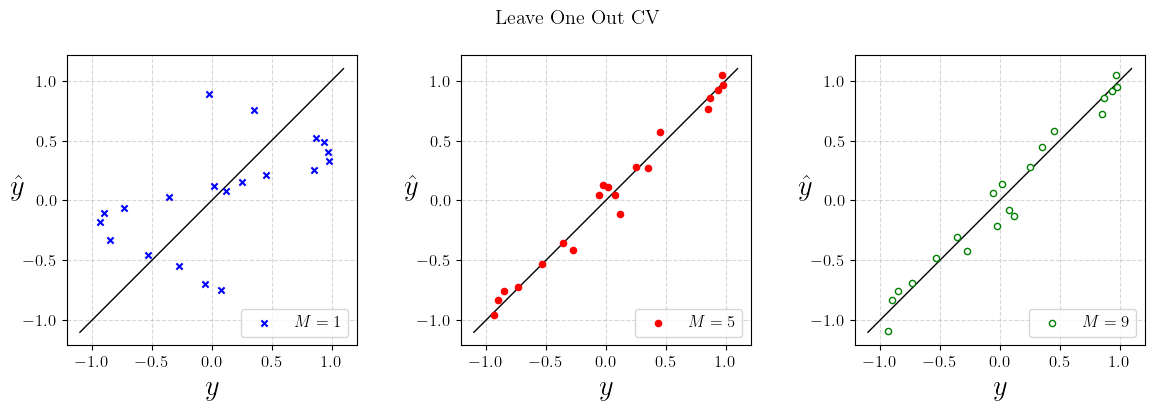

In [11]:
XX = np.hstack([xtrain, x_test])
YY = np.hstack([ytrain, y_test])
YY1 , YY5, YY9 = [], [], []
for i, row in enumerate(XX):
    W = Polynomial.fit(np.delete(XX, i), np.delete(YY, i), deg=1)
    YY1 = np.hstack([YY1, W(XX[i])])
    W = Polynomial.fit(np.delete(XX, i), np.delete(YY, i), deg=5)
    YY5 = np.hstack([YY5, W(XX[i])])
    W = Polynomial.fit(np.delete(XX, i), np.delete(YY, i), deg=9)
    YY9 = np.hstack([YY9, W(XX[i])])
# %%
fig = plt.figure(figsize=(12., 4.), dpi=100, tight_layout=True)
gs  = GridSpec(1, 3) 
for m in range(3):
    ax  = plt.subplot(gs.new_subplotspec((0, m), 1, 1))
    if m == 0: 
        ax.scatter(YY, YY1, label='$M=1$', marker='x', s=20, color='blue', zorder=3)
    if m == 1: 
        ax.scatter(YY, YY5, label='$M=5$', marker='o', s=20, color='red', zorder=3)
    if m == 2: 
        ax.scatter(YY, YY9, label='$M=9$', marker='o', s=20, color='green', facecolor='white', zorder=3)
    ax.plot([-1.1, 1.1], [-1.1, 1.1], color='black', linewidth=1.0)
    ax.set_xlabel('$y$')
    ax.set_ylabel(r'$\hat{y}$', rotation='horizontal')
    ax.set_aspect('equal')
    ax.grid(linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
fig.suptitle('Leave One Out CV')
plt.show()

#### 検証方法の比較

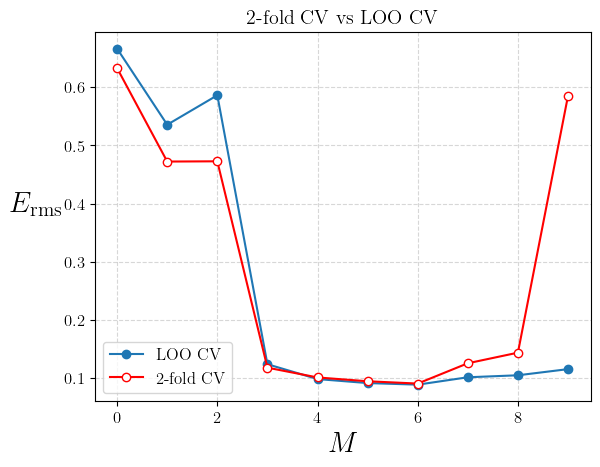

In [12]:
XX = np.hstack([xtrain, x_test])
YY = np.hstack([ytrain, y_test])
Erms_loo  = []
Erms_fold = []
for d in range(10):
    hat_YY = []
    for i, row in enumerate(XX):
        W = Polynomial.fit(np.delete(XX, i), np.delete(YY, i), deg=d)
        hat_YY = np.hstack([hat_YY, W(XX[i])])
    Erms_loo = np.hstack([Erms_loo, Erms(YY, hat_YY)])
    #
    W1 = Polynomial.fit(XX[ 0:10], YY[ 0:10], deg=d)
    W2 = Polynomial.fit(XX[10:20], YY[10:20], deg=d)
    Erms1 = Erms(YY[ 0:10], W2(XX[ 0:10]))
    Erms2 = Erms(YY[10:20], W1(XX[10:20]))
    Erms_fold = np.hstack([Erms_fold, (Erms1 + Erms2) / 2.0])
# %%
fig, ax = plt.subplots(dpi=100)
ax.plot(np.array(range(10)), Erms_loo,  marker='o', markersize=6, label='LOO CV')
ax.plot(np.array(range(10)), Erms_fold, marker='o', markersize=6, label='2-fold CV', color='red', markerfacecolor='white')
ax.set_xlabel('$M$')
ax.set_ylabel(r'$E_{\rm rms}$', rotation='horizontal', labelpad=20)
ax.grid(linestyle='--', alpha=0.5)
ax.set_title('2-fold CV vs LOO CV')
plt.legend(loc='lower left')
plt.show()